In [2]:
import pandas as pd
import matplotlib.pyplot as pIt

In [3]:
df= pd.read_csv("C:\Users\User\Desktop\data-mining-python-crispdm\data\X2-titanic .csv")
df.head()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3016518553.py, line 1)

In [4]:
df= pd.read_csv("..\data\X2-titanic .csv")
df.head()

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_21100\1572783439.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df= pd.read_csv("..\data\X2-titanic .csv")


,Unnamed: 0,class,age,sex,survived
0,1,1st class,adults,man,yes
1,2,1st class,adults,man,yes
2,3,1st class,adults,man,yes
3,4,1st class,adults,man,yes
4,5,1st class,adults,man,yes


In [5]:
df= pd.read_csv("../data/X2-titanic .csv")
df.head()

,Unnamed: 0,class,age,sex,survived
0,1,1st class,adults,man,yes
1,2,1st class,adults,man,yes
2,3,1st class,adults,man,yes
3,4,1st class,adults,man,yes
4,5,1st class,adults,man,yes


In [6]:
df=df.drop(columns=["Unnamed: 0"])
df.head()

,class,age,sex,survived
0,1st class,adults,man,yes
1,1st class,adults,man,yes
2,1st class,adults,man,yes
3,1st class,adults,man,yes
4,1st class,adults,man,yes


In [7]:
df["survived"].value_counts()

survived
no     817
yes    499
Name: count, dtype: int64

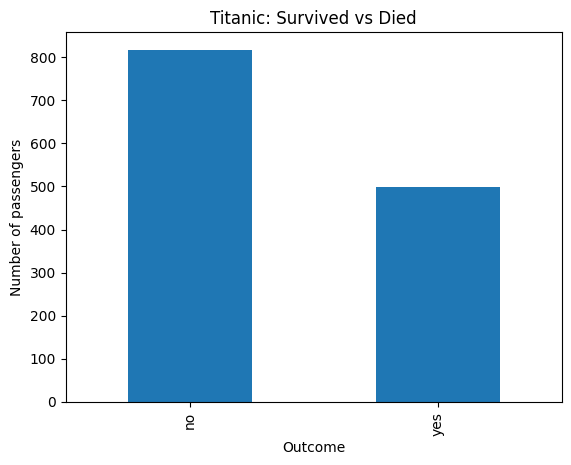

In [9]:
df["survived"].value_counts().plot(kind="bar")
pIt.title("Titanic: Survived vs Died")
pIt.xlabel("Outcome")
pIt.ylabel("Number of passengers")
pIt.show()

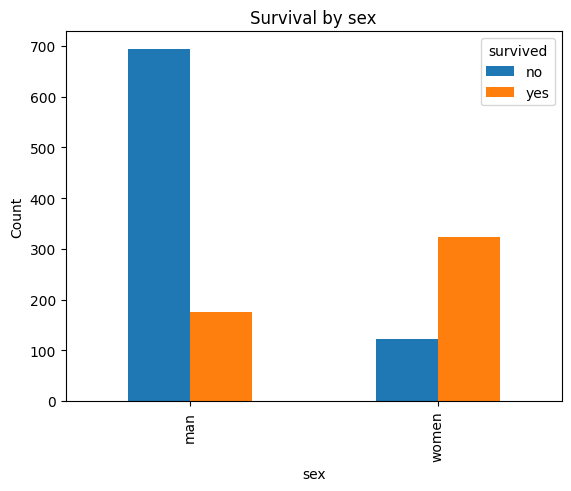

In [12]:
import matplotlib.pyplot as pIt
pd.crosstab(df["sex"],df["survived"]).plot(kind="bar")
pIt.title("Survival by sex")
pIt.ylabel("Count")
pIt.show()

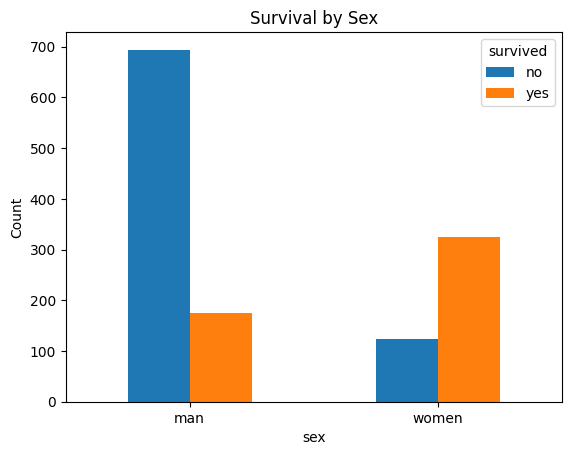

In [14]:
pd.crosstab(df["sex"], df["survived"]).plot(kind="bar")
pIt.title("Survival by Sex")
pIt.ylabel("Count")
pIt.xticks(rotation=0)
pIt.show()


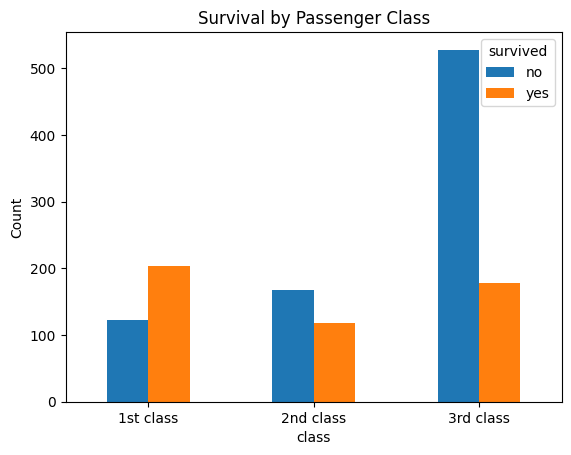

In [15]:
pd.crosstab(df["class"], df["survived"]).plot(kind="bar")
pIt.title("Survival by Passenger Class")
pIt.ylabel("Count")
pIt.xticks(rotation=0)
pIt.show()


In [16]:
pIt.savefig("../reports/figures/titanic_survival_by_sex.png", dpi=200, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

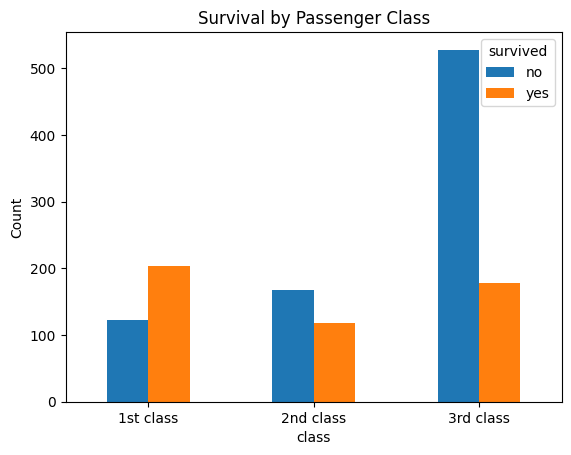

In [18]:
pd.crosstab(df["class"], df["survived"]).plot(kind="bar")
pIt.title("Survival by Passenger Class")
pIt.ylabel("Count")
pIt.xticks(rotation=0)
pIt.savefig("../reports/figures/titanic_survival_by_passenger_class.png", dpi=200, bbox_inches="tight")
pIt.show()


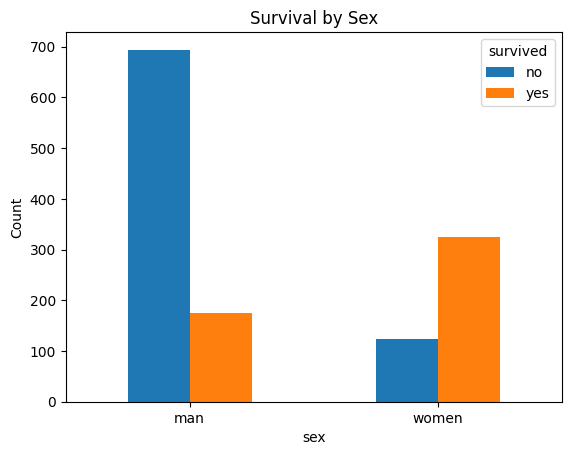

In [20]:
pd.crosstab(df["sex"], df["survived"]).plot(kind="bar")
pIt.title("Survival by Sex")
pIt.ylabel("Count")
pIt.xticks(rotation=0)
pIt.savefig("../reports/figures/titanic_survival_by_sex.png", dpi=200, bbox_inches="tight")
pIt.show()

In [21]:
X = df.drop("survived", axis=1)
y = df["survived"]

X.head(), y.head()


(       class     age  sex
 0  1st class  adults  man
 1  1st class  adults  man
 2  1st class  adults  man
 3  1st class  adults  man
 4  1st class  adults  man,
 0    yes
 1    yes
 2    yes
 3    yes
 4    yes
 Name: survived, dtype: object)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score


In [23]:
categorical_columns = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

model = Pipeline([
    ("prep", preprocessor),
    ("tree", DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ))
])


In [24]:
scores = cross_val_score(model, X, y, cv=10, scoring="accuracy")

print("Accuracy per fold:", scores)
print("Mean accuracy:", scores.mean())


Accuracy per fold: [0.62121212 0.91666667 1.         0.90151515 0.89393939 1.
 0.77862595 0.61832061 0.61832061 0.45801527]
Mean accuracy: 0.7806615776081425


[[765  52]
 [236 263]]


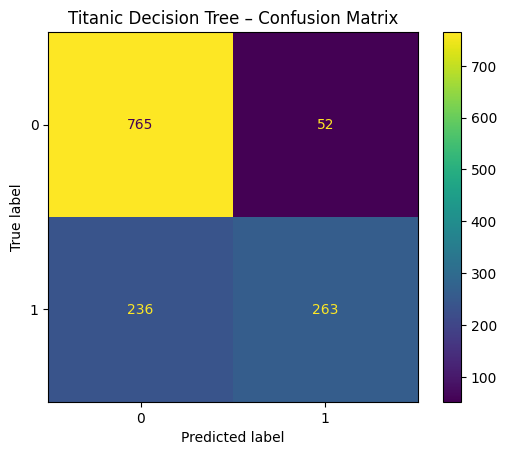

In [25]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cross_val_predict(model, X, y, cv=10)

cm = confusion_matrix(y, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Titanic Decision Tree – Confusion Matrix")
plt.show()


In [26]:
model_balanced = Pipeline([
    ("prep", preprocessor),
    ("tree", DecisionTreeClassifier(
        criterion="entropy",
        class_weight="balanced",  # ⭐ THIS IS THE FIX
        random_state=42
    ))
])


In [27]:
scores_balanced = cross_val_score(
    model_balanced, X, y, cv=10, scoring="accuracy"
)

print("Balanced accuracy per fold:", scores_balanced)
print("Balanced mean accuracy:", scores_balanced.mean())


Balanced accuracy per fold: [0.62121212 0.91666667 1.         0.90151515 0.89393939 1.
 0.77862595 0.64885496 0.54961832 0.3740458 ]
Balanced mean accuracy: 0.7684478371501273


[[659 158]
 [146 353]]


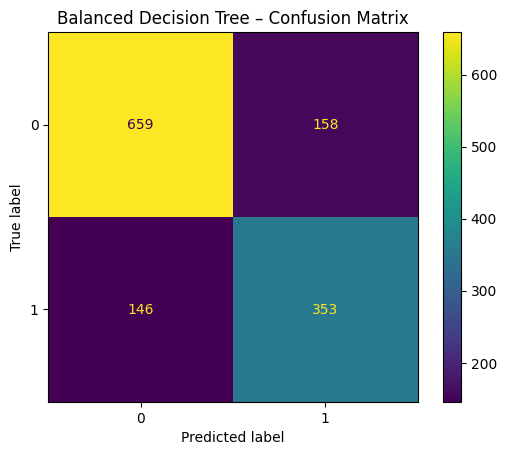

In [30]:
y_pred_bal = cross_val_predict(
    model_balanced, X, y, cv=10
)

cm_bal = confusion_matrix(y, y_pred_bal)
print(cm_bal)

disp = ConfusionMatrixDisplay(cm_bal)
disp.plot()
plt.title("Balanced Decision Tree – Confusion Matrix")
plt.savefig("../reports/figures/titanic_confusion_matrix_balanced.png",
            dpi=200, bbox_inches="tight")
plt.show()


In [33]:
git add .
git commit -m "Improve Titanic model using class-weighted decision tree"
git push


SyntaxError: invalid syntax (618379717.py, line 1)